# Entity-related hypnodensity analysis

This notebook analyses the EEG hypnodensity associated with the presence (`1`) versus absence (`0`) of reported entities during the DMT session. It is self-contained and uses only the `Entities` worksheet and persisted EEG hypnodensities.

The notebook contains three parallel analyses for Wake, N1, REM, and entropy: raw-probability change from each electrode's pre-infusion baseline mean, logit-transformed change from that same baseline mean, and raw-probability z-scores calculated only across paired post-infusion ratings within each subject-electrode. Electrodes remain as observations in all LMEs and are accounted for with an electrode variance component.


## 1. Imports and fixed analysis settings

The worksheet columns `D:O` are assigned the same sampling-time mapping used for the paired EEG windows: `0, 1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30` minutes. A rating at time *t* is paired with the overlap-weighted EEG probability in the 60 seconds ending at *t* after the 14-minute recording offset.


In [54]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'outputs').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

RATINGS_PATH = Path('/home/rherzoga/Documentos/Projects/Timmerman/data/ES_ratings.xlsx')
RUN_NAME = 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RUN_ROOT = PROJECT_ROOT / 'outputs' / RUN_NAME
RECORDINGS_DIR = RUN_ROOT / 'recordings'
OUTPUT_DIR = RUN_ROOT.parent / 'entities_lme_analysis_gssc_v4_logit_baseline_centered'
FIGURES_DIR = OUTPUT_DIR / 'figures'
RAW_OUTPUT_DIR = RUN_ROOT.parent / 'entities_lme_analysis_gssc_v4_raw_probability_baseline_centered'
RAW_FIGURES_DIR = RAW_OUTPUT_DIR / 'figures'
POST_Z_OUTPUT_DIR = RUN_ROOT.parent / 'entities_lme_analysis_gssc_v4_postinfusion_zscore'
POST_Z_FIGURES_DIR = POST_Z_OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
POST_Z_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
POST_Z_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TIMEPOINTS_MIN = (0, 1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30)
EEG_OFFSET_SECONDS = 14 * 60
WINDOW_SECONDS = 60
INFUSION_START_SECONDS = 14 * 60
STAGER = 'gssc'
PROBABILITIES = ('prob_W', 'prob_N1', 'prob_N2', 'prob_N3', 'prob_R')
RESPONSES = ('prob_W', 'prob_N1', 'prob_R', 'entropy')
RESPONSE_LABELS = {'prob_W': 'Wake', 'prob_N1': 'N1', 'prob_R': 'REM', 'entropy': 'Entropy'}
ENTITY_LABELS = {0: 'No entity', 1: 'Entity'}
MODEL_FORMULA = 'response ~ entity'
LOGIT_EPSILON = 1e-6

plt.rcParams.update({
    'font.family': 'Liberation Sans', 'font.sans-serif': ['Liberation Sans'],
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

assert len(TIMEPOINTS_MIN) == 12
display({'entities_file': str(RATINGS_PATH), 'recordings': str(RECORDINGS_DIR), 'formula': MODEL_FORMULA})


{'entities_file': '/home/rherzoga/Documentos/Projects/Timmerman/data/ES_ratings.xlsx',
 'recordings': '/home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1/recordings',
 'formula': 'response ~ entity'}

## 2. Entity ratings and EEG pairing

Only `0` (absence) and `1` (presence) are analysed. The ambiguous value `0.5`, text entries, and missing values are excluded. The pairing uses the overlap-weighted 60-second window ending at each rating time. A paired electrode is retained only when that subject-electrode has a strictly pre-infusion baseline.


In [55]:
subject_column = pd.read_excel(RATINGS_PATH, sheet_name='Entities', header=None, usecols='A').iloc[:, 0]
entities_wide = pd.read_excel(RATINGS_PATH, sheet_name='Entities', header=None, usecols='D:O')
entities_wide.columns = TIMEPOINTS_MIN
entities_wide.insert(0, 'subject', subject_column.astype(str))
entity_ratings = entities_wide.melt('subject', var_name='timepoint', value_name='entity')
entity_ratings['timepoint'] = entity_ratings['timepoint'].astype(int)
entity_ratings['entity'] = pd.to_numeric(entity_ratings['entity'], errors='coerce')
entity_ratings = entity_ratings.loc[entity_ratings['entity'].isin([0, 1])].copy()
entity_ratings['entity'] = entity_ratings['entity'].astype(int)
entity_ratings['eeg_window_end'] = EEG_OFFSET_SECONDS + entity_ratings['timepoint'] * 60
entity_ratings['eeg_window_start'] = entity_ratings['eeg_window_end'] - WINDOW_SECONDS

files = sorted(RECORDINGS_DIR.glob('*_hypnodensities.parquet'))
if not files:
    raise FileNotFoundError(f'No persisted hypnodensity files found in {RECORDINGS_DIR}.')
eeg = pd.concat([pd.read_parquet(file) for file in files], ignore_index=True)
eeg = eeg.loc[
    eeg['condition'].astype(str).eq('DMT') & eeg['stager'].astype(str).eq(STAGER)
].copy()
entity_ratings = entity_ratings.loc[entity_ratings['subject'].isin(eeg['subject'].astype(str).unique())].copy()

def normalized_entropy(values):
    values = np.asarray(values, dtype=float)
    return -np.where(values > 0, values * np.log(values), 0.0).sum() / np.log(len(PROBABILITIES))

def logit(values, epsilon=LOGIT_EPSILON):
    clipped = np.clip(np.asarray(values, dtype=float), epsilon, 1 - epsilon)
    return np.log(clipped / (1 - clipped))

# Each epoch is transformed before baseline and post-infusion summaries are
# calculated. This keeps the response definition identical on both sides of
# the pairing while bounding probabilities away from 0 and 1.
eeg['entropy'] = eeg[list(PROBABILITIES)].apply(normalized_entropy, axis=1)
for response in RESPONSES:
    eeg[f'{response}_logit'] = logit(eeg[response].to_numpy(dtype=float))
TRANSFORMED_RESPONSES = [f'{response}_logit' for response in RESPONSES]

baseline_epochs = eeg.loc[eeg['absolute_end'].le(INFUSION_START_SECONDS)].copy()
# Raw-probability baseline mean for the first analysis section.
raw_baseline_mean = (
    baseline_epochs.groupby(['subject', 'electrode'], observed=True)[list(RESPONSES)]
    .mean()
)

baseline_mean = (
    baseline_epochs.groupby(['subject', 'electrode'], observed=True)[TRANSFORMED_RESPONSES]
    .mean()
)


window_rows, raw_window_rows, coverage_rows = [], [], []
for rating in entity_ratings.itertuples(index=False):
    candidates = eeg.loc[
        eeg['subject'].astype(str).eq(rating.subject)
        & eeg['absolute_start'].lt(rating.eeg_window_end)
        & eeg['absolute_end'].gt(rating.eeg_window_start)
    ].copy()
    candidates['overlap_seconds'] = (
        np.minimum(candidates['absolute_end'], rating.eeg_window_end)
        - np.maximum(candidates['absolute_start'], rating.eeg_window_start)
    )
    candidates = candidates.loc[candidates['overlap_seconds'].gt(0)]
    coverage_rows.append({
        'subject': rating.subject, 'timepoint': rating.timepoint, 'entity': rating.entity,
        'n_overlapping_epochs': len(candidates),
        'overlap_seconds_all_electrodes': candidates['overlap_seconds'].sum(),
        'n_electrodes_with_overlap': candidates['electrode'].nunique(),
    })
    for electrode, epochs in candidates.groupby('electrode', observed=True):
        baseline_key = (rating.subject, electrode)
        if baseline_key not in baseline_mean.index:
            continue
        post_values = np.average(epochs[TRANSFORMED_RESPONSES], axis=0, weights=epochs['overlap_seconds'])
        reference_mean = baseline_mean.loc[baseline_key, TRANSFORMED_RESPONSES].to_numpy(dtype=float)
        logit_change = post_values - reference_mean
        window_rows.append({
            'subject': rating.subject, 'timepoint': rating.timepoint, 'entity': rating.entity,
            'electrode': electrode,
            'prob_W': logit_change[0], 'prob_N1': logit_change[1],
            'prob_R': logit_change[2], 'entropy': logit_change[3],
        })
        post_raw_values = np.average(epochs[list(RESPONSES)], axis=0, weights=epochs['overlap_seconds'])
        raw_reference_mean = raw_baseline_mean.loc[baseline_key, list(RESPONSES)].to_numpy(dtype=float)
        raw_change = post_raw_values - raw_reference_mean
        raw_window_rows.append({
            'subject': rating.subject, 'timepoint': rating.timepoint, 'entity': rating.entity,
            'electrode': electrode,
            'prob_W': raw_change[0], 'prob_N1': raw_change[1],
            'prob_R': raw_change[2], 'entropy': raw_change[3],
        })

entity_electrode = pd.DataFrame(window_rows)
entity_electrode_raw = pd.DataFrame(raw_window_rows)
coverage = pd.DataFrame(coverage_rows)
valid_rating_keys = entity_electrode[['subject', 'timepoint']].drop_duplicates()
coverage['has_valid_eeg_pair'] = coverage.set_index(['subject', 'timepoint']).index.isin(
    valid_rating_keys.set_index(['subject', 'timepoint']).index
)
coverage_by_timepoint = (coverage.groupby(['timepoint', 'entity'], observed=True)
    .agg(ratings_in_sheet=('subject', 'size'), valid_ratings=('has_valid_eeg_pair', 'sum'),
         valid_subjects=('subject', lambda x: x[coverage.loc[x.index, 'has_valid_eeg_pair']].nunique()))
    .reset_index())

entity_electrode.to_parquet(OUTPUT_DIR / 'entity_electrode_logit_baseline_centered.parquet', index=False)
entity_timepoint_logit = (
    entity_electrode.groupby(['subject', 'timepoint', 'entity'], observed=True)[list(RESPONSES)]
    .mean().reset_index()
)
entity_timepoint_logit.to_csv(OUTPUT_DIR / 'entity_timepoint_logit_baseline_centered_means.csv', index=False)
entity_electrode_raw.to_parquet(RAW_OUTPUT_DIR / 'entity_electrode_raw_probability_baseline_centered.parquet', index=False)
coverage.to_csv(OUTPUT_DIR / 'entity_eeg_coverage.csv', index=False)
coverage_by_timepoint.to_csv(OUTPUT_DIR / 'entity_eeg_coverage_by_timepoint.csv', index=False)
display(coverage_by_timepoint)
display({
    'valid paired ratings': int(coverage['has_valid_eeg_pair'].sum()),
    'valid subjects': entity_electrode['subject'].nunique(),
    'electrode-level observations': len(entity_electrode),
})


,timepoint,entity,ratings_in_sheet,valid_ratings,valid_subjects
0,0,0,18,13,13
1,1,0,12,1,1
2,1,1,6,0,0
3,2,0,10,1,1
4,2,1,8,1,1
5,3,0,8,0,0
6,3,1,10,2,2
7,4,0,7,1,1
8,4,1,10,2,2
9,6,0,10,2,2


{'valid paired ratings': 52,
 'valid subjects': 16,
 'electrode-level observations': 1664}

## 3. Raw-probability change from baseline

For each response, the first analysis uses the natural probability or entropy scale:

`post-infusion value − subject-electrode baseline mean`

The pairing and electrode eligibility are identical to the later logit analysis. The only difference is that no logit transformation or SD scaling is applied.


In [56]:
def benjamini_hochberg_raw(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan)
    finite = np.flatnonzero(np.isfinite(p_values))
    if finite.size:
        ordered = finite[np.argsort(p_values[finite])]
        ranked = p_values[ordered] * finite.size / np.arange(1, finite.size + 1)
        adjusted[ordered] = np.minimum.accumulate(ranked[::-1])[::-1].clip(max=1)
    return adjusted

def fit_raw_entity_lme(model_data):
    last_error = None
    for optimizer in ('lbfgs', 'bfgs', 'cg', 'powell'):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                fit = smf.mixedlm(
                    MODEL_FORMULA, data=model_data, groups=model_data['subject'], re_formula='1',
                    vc_formula={'electrode': '0 + C(electrode)'},
                ).fit(reml=False, method=optimizer, maxiter=1000, disp=False)
            return fit, optimizer
        except np.linalg.LinAlgError as error:
            last_error = error
    raise last_error

raw_model_rows = []
for response_name in RESPONSES:
    model_data = (entity_electrode_raw[['subject', 'timepoint', 'electrode', 'entity', response_name]]
                  .dropna().rename(columns={response_name: 'response'}))
    fit, optimizer = fit_raw_entity_lme(model_data)
    ci = fit.conf_int().loc['entity']
    raw_model_rows.append({
        'response': RESPONSE_LABELS[response_name], 'outcome_column': response_name,
        'term': 'Entity present minus absent', 'beta': float(fit.fe_params['entity']),
        'standard_error': float(fit.bse_fe['entity']),
        'ci95_low': float(ci.iloc[0]), 'ci95_high': float(ci.iloc[1]),
        'z_value': float(fit.tvalues['entity']), 'p_value': float(fit.pvalues['entity']),
        'n_subjects': int(model_data['subject'].nunique()),
        'n_electrode_observations': int(len(model_data)),
        'n_paired_ratings': int(model_data[['subject', 'timepoint']].drop_duplicates().shape[0]),
        'converged': bool(fit.converged), 'optimizer': optimizer,
    })
raw_lme_results = pd.DataFrame(raw_model_rows)
raw_lme_results['p_fdr_bh'] = benjamini_hochberg_raw(raw_lme_results['p_value'])
raw_lme_results.to_csv(RAW_OUTPUT_DIR / 'entity_hypnodensity_lme_results_raw_probability_baseline_centered.csv', index=False)
display(raw_lme_results.round(4))


,response,outcome_column,term,beta,standard_error,ci95_low,ci95_high,z_value,p_value,n_subjects,n_electrode_observations,n_paired_ratings,converged,optimizer,p_fdr_bh
0,Wake,prob_W,Entity present minus absent,-0.0898,0.0205,-0.1300,-0.0496,-4.3790,0.0000,16,1664,52,True,lbfgs,0.0000
1,N1,prob_N1,Entity present minus absent,0.0655,0.0170,0.0321,0.0989,3.8449,0.0001,16,1664,52,True,lbfgs,0.0002
2,REM,prob_R,Entity present minus absent,0.0089,0.0031,0.0029,0.0149,2.9194,0.0035,16,1664,52,True,lbfgs,0.0035
3,Entropy,entropy,Entity present minus absent,0.0815,0.0117,0.0586,0.1044,6.9703,0.0000,16,1664,52,True,lbfgs,0.0000


## 4. Raw-probability baseline-centered figures

Both plots use the raw-probability baseline-centering from the preceding section. The first retains one mean per `subject × entity state`; the second retains every paired `subject × timepoint` observation. The forest plot reports outcome-SD-standardized LME coefficients; the LME result table retains raw coefficients.


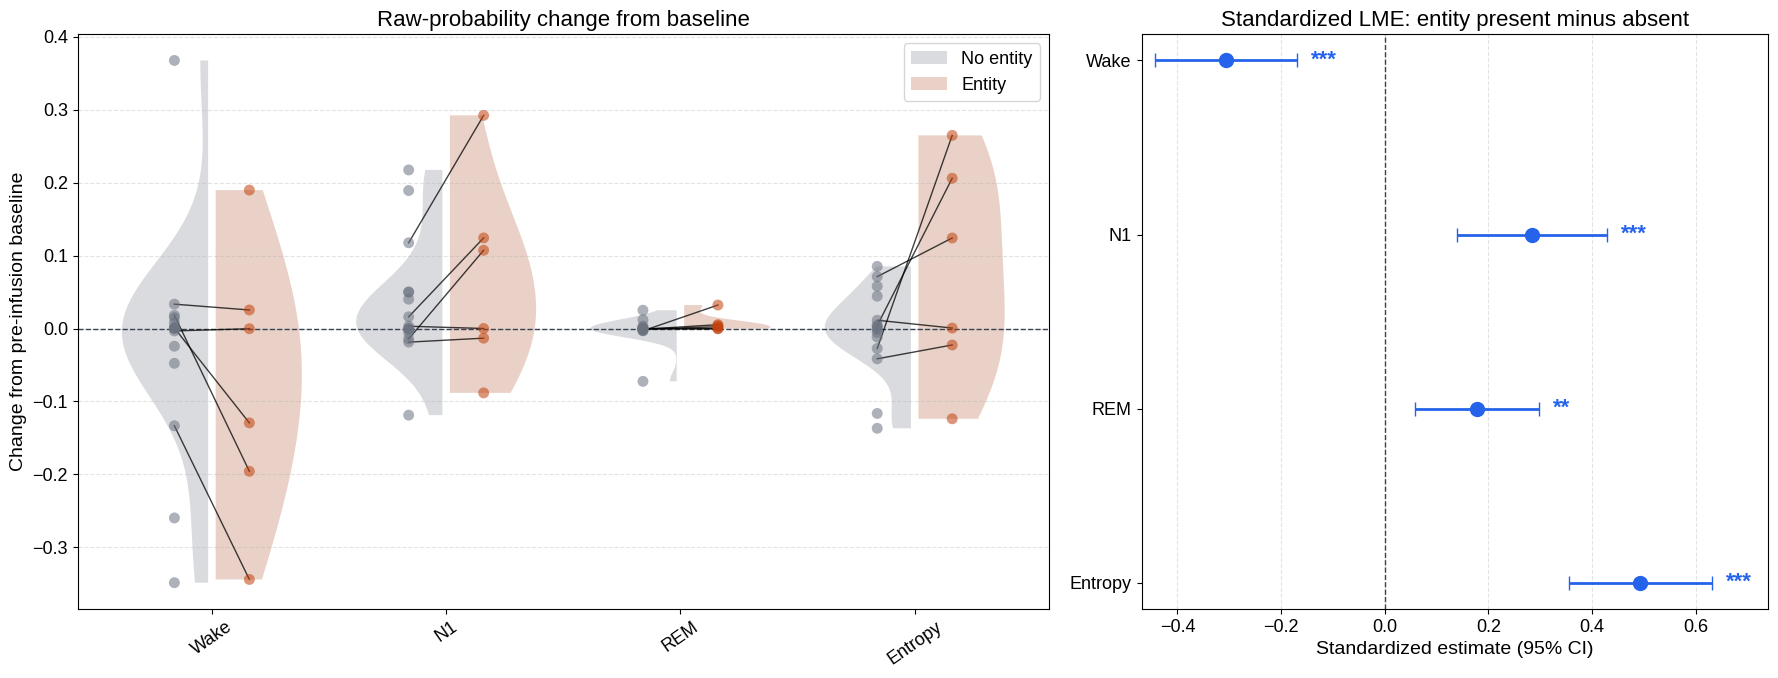

/home/rherzoga/miniconda3/envs/dmt_hypnodensities/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/rherzoga/miniconda3/envs/dmt_hypnodensities/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


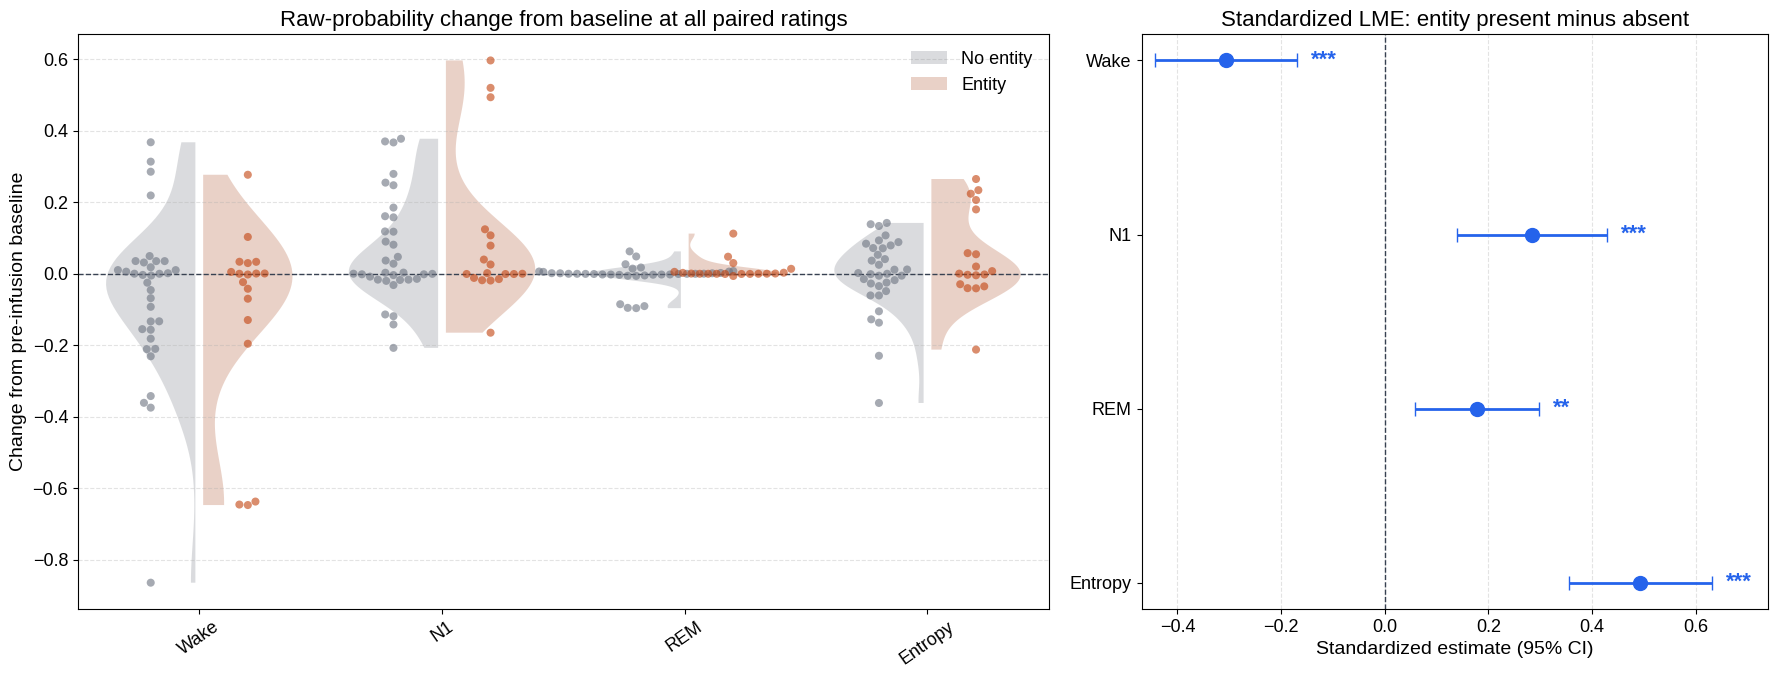

In [57]:
response_order = [RESPONSE_LABELS[response] for response in RESPONSES]
entity_order = [ENTITY_LABELS[0], ENTITY_LABELS[1]]
palette = {ENTITY_LABELS[0]: '#6b7280', ENTITY_LABELS[1]: '#c2410c'}
point_offsets = {ENTITY_LABELS[0]: -0.16, ENTITY_LABELS[1]: 0.16}

raw_subject_state_means = (
    entity_electrode_raw.groupby(['subject', 'entity'], observed=True)[list(RESPONSES)]
    .mean().reset_index()
)
raw_plot_data = raw_subject_state_means.melt(
    id_vars=['subject', 'entity'], value_vars=list(RESPONSES), var_name='response', value_name='value'
)
raw_plot_data['response'] = raw_plot_data['response'].map(RESPONSE_LABELS)
raw_plot_data['entity_label'] = raw_plot_data['entity'].map(ENTITY_LABELS)
# Standardize the entity coefficient and its uncertainty by the SD of the
# baseline-centered response across the same electrode-level model observations.
raw_standardized_lme = raw_lme_results.copy()
raw_response_sd = entity_electrode_raw[list(RESPONSES)].std(ddof=1)
raw_standardized_lme['response_sd'] = raw_standardized_lme['outcome_column'].map(raw_response_sd)
for column in ('beta', 'standard_error', 'ci95_low', 'ci95_high'):
    raw_standardized_lme[column] = raw_standardized_lme[column] / raw_standardized_lme['response_sd']
raw_standardized_lme.to_csv(
    RAW_OUTPUT_DIR / 'entity_hypnodensity_lme_results_raw_probability_standardized.csv', index=False
)
raw_effects = raw_standardized_lme.copy()
raw_effects['response'] = pd.Categorical(raw_effects['response'], categories=response_order, ordered=True)
raw_effects = raw_effects.sort_values('response').reset_index(drop=True)

figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(data=raw_plot_data, x='response', y='value', hue='entity_label',
    order=response_order, hue_order=entity_order, split=True, inner=None, palette=palette,
    cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.25)
for response_position, response in enumerate(response_order):
    response_subset = raw_plot_data.loc[raw_plot_data['response'].eq(response)]
    paired = response_subset.pivot(index='subject', columns='entity_label', values='value').dropna(subset=entity_order, how='any')
    for _, paired_subject in paired.iterrows():
        axis.plot([response_position + point_offsets[entity_order[0]], response_position + point_offsets[entity_order[1]]],
                  [paired_subject[entity_order[0]], paired_subject[entity_order[1]]], color='black', linewidth=1, alpha=0.75, zorder=3)
    for entity_label in entity_order:
        values = response_subset.loc[response_subset['entity_label'].eq(entity_label), 'value']
        axis.scatter(np.full(len(values), response_position + point_offsets[entity_label]), values,
                     s=62, color=palette[entity_label], edgecolor='none', alpha=0.55, zorder=4)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set(title='Raw-probability change from baseline', xlabel='', ylabel='Change from pre-infusion baseline')
axis.tick_params(axis='x', rotation=35); axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None: legend.set_title(None)

forest = axes[1]; y_positions = np.arange(len(raw_effects))
x_span = raw_effects['ci95_high'].max() - raw_effects['ci95_low'].min(); significance_offset = max(0.005, 0.025 * x_span)
for y, (_, row) in zip(y_positions, raw_effects.iterrows()):
    forest.errorbar(row['beta'], y, xerr=[[row['beta'] - row['ci95_low']], [row['ci95_high'] - row['beta']]], fmt='o', color='#2563eb', ecolor='#2563eb', capsize=5, markersize=10, linewidth=2)
    if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001: forest.text(row['ci95_high'] + significance_offset, y, '***', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.01: forest.text(row['ci95_high'] + significance_offset, y, '**', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.05: forest.text(row['ci95_high'] + significance_offset, y, '*', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
forest.axvline(0, color='#374151', linewidth=1, linestyle='--')
forest.set_xlim(raw_effects['ci95_low'].min() - significance_offset, raw_effects['ci95_high'].max() + 4 * significance_offset)
forest.set_yticks(y_positions, raw_effects['response']); forest.invert_yaxis()
forest.set(title='Standardized LME: entity present minus absent', xlabel='Standardized estimate (95% CI)')
forest.grid(axis='x', linestyle='--', alpha=0.35)
figure.tight_layout()
for extension in ('png', 'svg', 'pdf'): figure.savefig(RAW_FIGURES_DIR / f'entities_hypnodensities_by_state_and_lme_raw_probability_baseline_centered.{extension}', dpi=300, bbox_inches='tight')
plt.show()

raw_timepoint_means = entity_electrode_raw.groupby(['subject', 'timepoint', 'entity'], observed=True)[list(RESPONSES)].mean().reset_index()
raw_timepoint_means.to_csv(RAW_OUTPUT_DIR / 'entity_timepoint_raw_probability_baseline_centered_means.csv', index=False)
raw_all_points = raw_timepoint_means.melt(id_vars=['subject', 'timepoint', 'entity'], value_vars=list(RESPONSES), var_name='response', value_name='value')
raw_all_points['response'] = raw_all_points['response'].map(RESPONSE_LABELS); raw_all_points['entity_label'] = raw_all_points['entity'].map(ENTITY_LABELS)
figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(data=raw_all_points, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, split=True, inner=None, palette=palette, cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.25)
sns.swarmplot(data=raw_all_points, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, dodge=True, palette=palette, size=5.8, alpha=0.60, edgecolor='none', linewidth=0, ax=axis)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--'); axis.set(title='Raw-probability change from baseline at all paired ratings', xlabel='', ylabel='Change from pre-infusion baseline'); axis.tick_params(axis='x', rotation=35); axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None:
    handles, labels = axis.get_legend_handles_labels(); legend.remove(); axis.legend(handles[:2], labels[:2], title=None, frameon=False)
forest = axes[1]; y_positions = np.arange(len(raw_effects))
for y, (_, row) in zip(y_positions, raw_effects.iterrows()):
    forest.errorbar(row['beta'], y, xerr=[[row['beta'] - row['ci95_low']], [row['ci95_high'] - row['beta']]], fmt='o', color='#2563eb', ecolor='#2563eb', capsize=5, markersize=10, linewidth=2)
    if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001: forest.text(row['ci95_high'] + significance_offset, y, '***', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.01: forest.text(row['ci95_high'] + significance_offset, y, '**', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.05: forest.text(row['ci95_high'] + significance_offset, y, '*', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
forest.axvline(0, color='#374151', linewidth=1, linestyle='--'); forest.set_xlim(raw_effects['ci95_low'].min() - significance_offset, raw_effects['ci95_high'].max() + 4 * significance_offset); forest.set_yticks(y_positions, raw_effects['response']); forest.invert_yaxis(); forest.set(title='Standardized LME: entity present minus absent', xlabel='Standardized estimate (95% CI)'); forest.grid(axis='x', linestyle='--', alpha=0.35)
figure.tight_layout()
for extension in ('png', 'svg', 'pdf'): figure.savefig(RAW_FIGURES_DIR / f'entities_hypnodensities_all_rating_points_raw_probability_baseline_centered.{extension}', dpi=300, bbox_inches='tight')
plt.show()


## 5. Logit baseline-centered LME models

One model is fitted independently for each outcome:

`logit hypnodensity change from baseline ~ Entity + (1 | Subject) + electrode variance component`

The coefficient for `entity` is the estimated difference between entity-present (`1`) and entity-absent (`0`) ratings. Electrodes remain as model observations and are accounted for with an electrode variance component.


In [58]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan)
    finite = np.flatnonzero(np.isfinite(p_values))
    if finite.size:
        ordered = finite[np.argsort(p_values[finite])]
        ranked = p_values[ordered] * finite.size / np.arange(1, finite.size + 1)
        adjusted[ordered] = np.minimum.accumulate(ranked[::-1])[::-1].clip(max=1)
    return adjusted

def fit_entity_lme(model_data):
    last_error = None
    for optimizer in ('lbfgs', 'bfgs', 'cg', 'powell'):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                fit = smf.mixedlm(
                    MODEL_FORMULA, data=model_data, groups=model_data['subject'], re_formula='1',
                    vc_formula={'electrode': '0 + C(electrode)'},
                ).fit(reml=False, method=optimizer, maxiter=1000, disp=False)
            return fit, optimizer
        except np.linalg.LinAlgError as error:
            last_error = error
    raise last_error

model_rows = []
for response_name in RESPONSES:
    model_data = (entity_electrode[['subject', 'timepoint', 'electrode', 'entity', response_name]]
                  .dropna().rename(columns={response_name: 'response'}))
    fit, optimizer = fit_entity_lme(model_data)
    ci = fit.conf_int().loc['entity']
    model_rows.append({
        'response': RESPONSE_LABELS[response_name], 'outcome_column': response_name,
        'term': 'Entity present minus absent', 'beta': float(fit.fe_params['entity']),
        'standard_error': float(fit.bse_fe['entity']),
        'ci95_low': float(ci.iloc[0]), 'ci95_high': float(ci.iloc[1]),
        'z_value': float(fit.tvalues['entity']), 'p_value': float(fit.pvalues['entity']),
        'n_subjects': int(model_data['subject'].nunique()),
        'n_electrode_observations': int(len(model_data)),
        'n_paired_ratings': int(model_data[['subject', 'timepoint']].drop_duplicates().shape[0]),
        'n_entity_present_ratings': int(model_data.loc[model_data['entity'].eq(1), ['subject', 'timepoint']].drop_duplicates().shape[0]),
        'n_entity_absent_ratings': int(model_data.loc[model_data['entity'].eq(0), ['subject', 'timepoint']].drop_duplicates().shape[0]),
        'converged': bool(fit.converged), 'optimizer': optimizer,
    })

entity_lme_results = pd.DataFrame(model_rows)
entity_lme_results['p_fdr_bh'] = benjamini_hochberg(entity_lme_results['p_value'])
entity_lme_results.to_csv(OUTPUT_DIR / 'entity_hypnodensity_lme_results.csv', index=False)
display(entity_lme_results.round(4))


,response,outcome_column,term,beta,standard_error,ci95_low,ci95_high,z_value,p_value,n_subjects,n_electrode_observations,n_paired_ratings,n_entity_present_ratings,n_entity_absent_ratings,converged,optimizer,p_fdr_bh
0,Wake,prob_W,Entity present minus absent,-1.7586,0.2228,-2.1953,-1.3219,-7.8929,0.0,16,1664,52,18,34,True,lbfgs,0.0
1,N1,prob_N1,Entity present minus absent,1.5549,0.1832,1.1958,1.9141,8.4861,0.0,16,1664,52,18,34,False,lbfgs,0.0
2,REM,prob_R,Entity present minus absent,1.1619,0.1298,0.9075,1.4163,8.9514,0.0,16,1664,52,18,34,True,lbfgs,0.0
3,Entropy,entropy,Entity present minus absent,1.2696,0.1250,1.0246,1.5146,10.1564,0.0,16,1664,52,18,34,True,lbfgs,0.0


## 6. Logit baseline-centered state figure

For visualization, electrode-level standardized logit values are first averaged within each `subject × entity state` cell. The paired subject lines are shown only for subjects with both states. The forest plot reports the primary LME entity coefficients and their 95% confidence intervals.


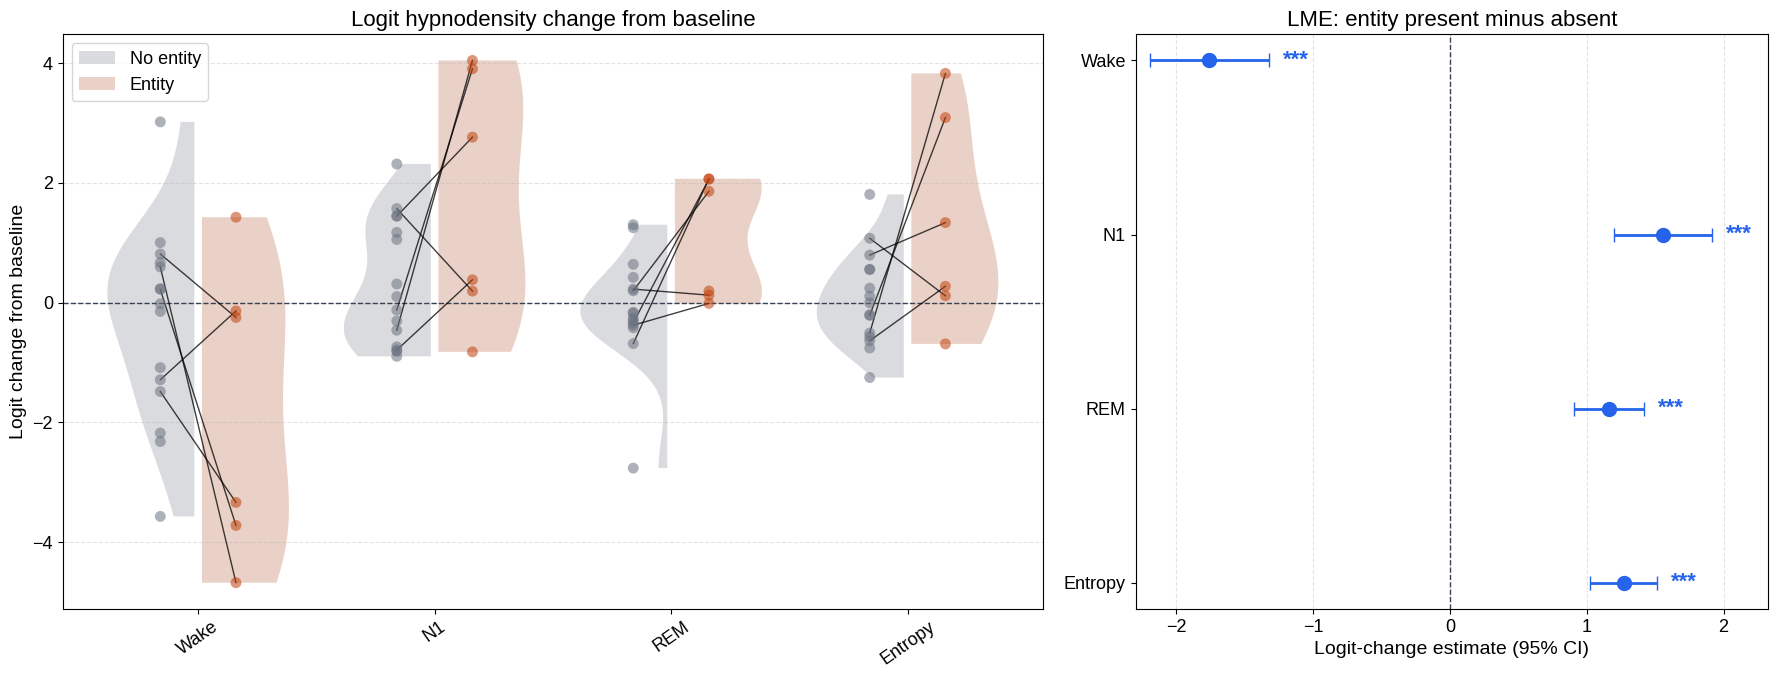

,subject,entity,prob_W,prob_N1,prob_R,entropy
0,P07,0,3.020911,-0.895305,-0.178316,-0.756359
1,P08,0,0.814161,-0.790067,-0.375588,-0.635237
2,P08,1,-0.246234,0.383111,-0.011024,0.274252
3,P09,0,-3.568644,1.175239,0.424223,0.243427
4,P10,0,-1.084440,1.056730,0.641578,0.553045
5,P11,0,0.235355,-0.303800,-0.159575,-0.201220
6,P13,0,-2.318646,1.448753,1.251750,0.558032
7,P15,1,1.428539,-0.820514,0.195867,-0.687908
8,P17,0,-1.482706,1.445543,0.199538,0.795899
9,P17,1,-3.335081,2.765468,1.861742,1.337893


'Saved figure files to /home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/entities_lme_analysis_gssc_v4_logit_baseline_centered/figures'

In [59]:
subject_state_means = (
    entity_timepoint_logit.groupby(['subject', 'entity'], observed=True)[list(RESPONSES)]
    .mean().reset_index()
)
plot_data = subject_state_means.melt(
    id_vars=['subject', 'entity'], value_vars=list(RESPONSES),
    var_name='response', value_name='value',
)
plot_data['response'] = plot_data['response'].map(RESPONSE_LABELS)
plot_data['entity_label'] = plot_data['entity'].map(ENTITY_LABELS)
response_order = [RESPONSE_LABELS[response] for response in RESPONSES]
entity_order = [ENTITY_LABELS[0], ENTITY_LABELS[1]]
palette = {ENTITY_LABELS[0]: '#6b7280', ENTITY_LABELS[1]: '#c2410c'}
point_offsets = {ENTITY_LABELS[0]: -0.16, ENTITY_LABELS[1]: 0.16}

figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(
    data=plot_data, x='response', y='value', hue='entity_label',
    order=response_order, hue_order=entity_order, split=True, inner=None,
    palette=palette, cut=0, density_norm='width', gap=0.08, fill=True,
    linewidth=0, ax=axis, edgecolor='none', alpha=0.25,
)
for response_position, response in enumerate(response_order):
    response_subset = plot_data.loc[plot_data['response'].eq(response)]
    paired = response_subset.pivot(index='subject', columns='entity_label', values='value')
    paired = paired.dropna(subset=entity_order, how='any')
    for _, paired_subject in paired.iterrows():
        axis.plot(
            [response_position + point_offsets[entity_order[0]], response_position + point_offsets[entity_order[1]]],
            [paired_subject[entity_order[0]], paired_subject[entity_order[1]]],
            color='black', linewidth=1, alpha=0.75, zorder=3,
        )
    for entity_label in entity_order:
        values = response_subset.loc[response_subset['entity_label'].eq(entity_label), 'value']
        axis.scatter(
            np.full(len(values), response_position + point_offsets[entity_label]), values,
            s=62, color=palette[entity_label], edgecolor='none', alpha=0.55, zorder=4,
        )
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set_title('Logit hypnodensity change from baseline')
axis.set_xlabel('')
axis.set_ylabel('Logit change from baseline')
axis.tick_params(axis='x', rotation=35)
axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None:
    legend.set_title(None)

# The outcome is already expressed in each electrode's baseline SD units.
# The forest plot therefore uses these coefficients directly and does not apply
# a second, post-infusion outcome-SD standardization.
standardized_lme = entity_lme_results.copy()
standardized_lme.to_csv(OUTPUT_DIR / 'entity_hypnodensity_lme_results_logit_baseline_centered.csv', index=False)

forest = axes[1]
forest_data = standardized_lme.copy()
forest_data['response'] = pd.Categorical(forest_data['response'], categories=response_order, ordered=True)
forest_data = forest_data.sort_values('response').reset_index(drop=True)
y_positions = np.arange(len(forest_data))
x_span = forest_data['ci95_high'].max() - forest_data['ci95_low'].min()
significance_offset = max(0.005, 0.025 * x_span)
for y, (_, row) in zip(y_positions, forest_data.iterrows()):
    forest.errorbar(
        row['beta'], y,
        xerr=[[row['beta'] - row['ci95_low']], [row['ci95_high'] - row['beta']]],
        fmt='o', color='#2563eb', ecolor='#2563eb', capsize=5, markersize=10, linewidth=2,
    )
    if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001:
        forest.text(row['ci95_high'] + significance_offset, y, '***', color='#2563eb',
                    fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.01:
        forest.text(row['ci95_high'] + significance_offset, y, '**', color='#2563eb',
                    fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.05:
        forest.text(row['ci95_high'] + significance_offset, y, '*', color='#2563eb',
                    fontsize=16, va='center', ha='left', fontweight='bold')
forest.axvline(0, color='#374151', linewidth=1, linestyle='--')
forest.set_xlim(forest_data['ci95_low'].min() - significance_offset,
                forest_data['ci95_high'].max() + 4 * significance_offset)
forest.set_yticks(y_positions, forest_data['response'])
forest.invert_yaxis()
forest.set_title('LME: entity present minus absent')
forest.set_xlabel('Logit-change estimate (95% CI)')
forest.grid(axis='x', linestyle='--', alpha=0.35)

figure.tight_layout()
for extension in ('png', 'svg', 'pdf'):
    figure.savefig(FIGURES_DIR / f'entities_hypnodensities_by_state_and_lme_logit_baseline_centered.{extension}', dpi=300, bbox_inches='tight')
plt.show()
display(subject_state_means.sort_values(['subject', 'entity']))
display(f'Saved figure files to {FIGURES_DIR}')


## 7. Logit baseline-centered all-rating figure

This visualization retains every valid paired `subject × timepoint` observation. For each rating, the logit changes from baseline are first averaged over the available electrodes. The violins therefore compare all entity-present and entity-absent rating-level observations during the infusion period, rather than one summary value per subject and state.


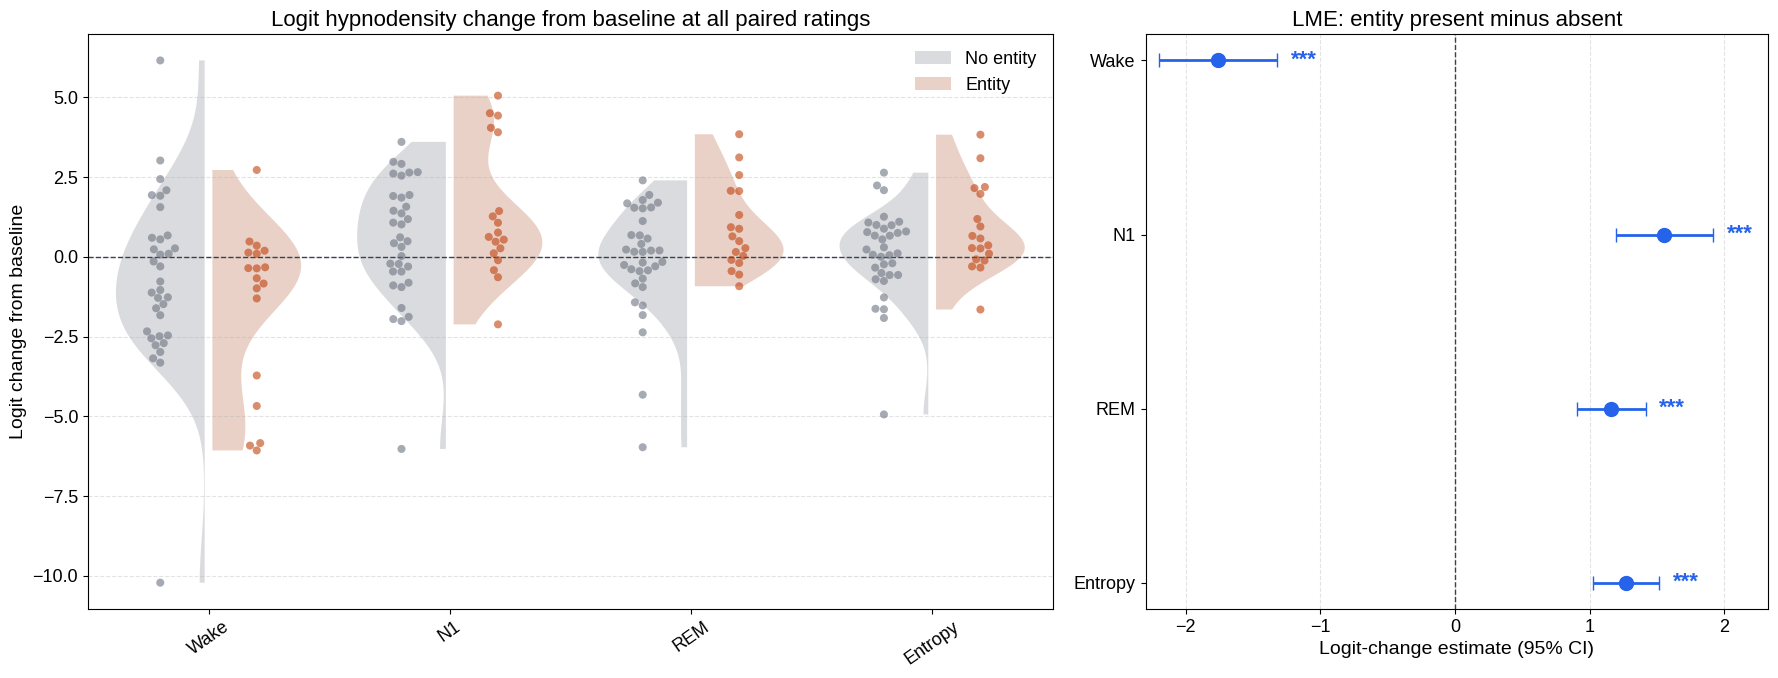

,subject,timepoint,entity,response,value,entity_label
156,P07,0,0,Entropy,-0.756359,No entity
157,P08,0,0,Entropy,-1.273000,No entity
158,P08,10,0,Entropy,0.002527,No entity
163,P09,0,0,Entropy,-0.569318,No entity
164,P09,14,0,Entropy,0.999983,No entity
...,...,...,...,...,...,...
35,P22,4,1,Wake,-3.719397,Entity
39,P23,2,1,Wake,-0.670591,Entity
40,P23,3,1,Wake,0.097444,Entity
41,P23,10,1,Wake,0.351933,Entity


'Saved figure files to /home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/entities_lme_analysis_gssc_v4_logit_baseline_centered/figures'

In [60]:
entity_timepoint_means = entity_timepoint_logit.copy()
entity_timepoint_means.to_csv(
    OUTPUT_DIR / 'entity_timepoint_logit_baseline_centered_means.csv', index=False
)
all_points_plot_data = entity_timepoint_means.melt(
    id_vars=['subject', 'timepoint', 'entity'], value_vars=list(RESPONSES),
    var_name='response', value_name='value',
)
all_points_plot_data['response'] = all_points_plot_data['response'].map(RESPONSE_LABELS)
all_points_plot_data['entity_label'] = all_points_plot_data['entity'].map(ENTITY_LABELS)

# Same two-panel layout as the standardized state figure. The points are all
# paired rating observations, so no lines are drawn between them.
figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(
    data=all_points_plot_data, x='response', y='value', hue='entity_label',
    order=response_order, hue_order=entity_order, split=True, inner=None,
    palette=palette, cut=0, density_norm='width', gap=0.08, fill=True,
    linewidth=0, ax=axis, edgecolor='none', alpha=0.25,
)
sns.swarmplot(
    data=all_points_plot_data, x='response', y='value', hue='entity_label',
    order=response_order, hue_order=entity_order, dodge=True,
    palette=palette, size=5.8, alpha=0.60, edgecolor='none', linewidth=0, ax=axis,
)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set_title('Logit hypnodensity change from baseline at all paired ratings')
axis.set_xlabel('')
axis.set_ylabel('Logit change from baseline')
axis.tick_params(axis='x', rotation=35)
axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None:
    handles, labels = axis.get_legend_handles_labels()
    legend.remove()
    axis.legend(handles[:2], labels[:2], title=None, frameon=False)

forest = axes[1]
forest_data = standardized_lme.copy()
forest_data['response'] = pd.Categorical(forest_data['response'], categories=response_order, ordered=True)
forest_data = forest_data.sort_values('response').reset_index(drop=True)
y_positions = np.arange(len(forest_data))
x_span = forest_data['ci95_high'].max() - forest_data['ci95_low'].min()
significance_offset = max(0.005, 0.025 * x_span)
for y, (_, row) in zip(y_positions, forest_data.iterrows()):
    forest.errorbar(
        row['beta'], y,
        xerr=[[row['beta'] - row['ci95_low']], [row['ci95_high'] - row['beta']]],
        fmt='o', color='#2563eb', ecolor='#2563eb', capsize=5, markersize=10, linewidth=2,
    )
    if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001:
        forest.text(row['ci95_high'] + significance_offset, y, '***', color='#2563eb',
                    fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.01:
        forest.text(row['ci95_high'] + significance_offset, y, '**', color='#2563eb',
                    fontsize=16, va='center', ha='left', fontweight='bold')
    elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.05:
        forest.text(row['ci95_high'] + significance_offset, y, '*', color='#2563eb',
                    fontsize=16, va='center', ha='left', fontweight='bold')
forest.axvline(0, color='#374151', linewidth=1, linestyle='--')
forest.set_xlim(forest_data['ci95_low'].min() - significance_offset,
                forest_data['ci95_high'].max() + 4 * significance_offset)
forest.set_yticks(y_positions, forest_data['response'])
forest.invert_yaxis()
forest.set_title('LME: entity present minus absent')
forest.set_xlabel('Logit-change estimate (95% CI)')
forest.grid(axis='x', linestyle='--', alpha=0.35)

figure.tight_layout()
for extension in ('png', 'svg', 'pdf'):
    figure.savefig(
        FIGURES_DIR / f'entities_hypnodensities_all_rating_points_logit_baseline_centered.{extension}',
        dpi=300, bbox_inches='tight',
    )
plt.show()
display(all_points_plot_data.sort_values(['response', 'entity', 'subject', 'timepoint']))
display(f'Saved figure files to {FIGURES_DIR}')


## 8. Post-infusion-only z-score LME models

This analysis uses the same paired post-infusion electrode-level values, without logits. For each `subject × electrode × response`, values are standardized only across that electrode's available paired post-infusion ratings:

`z = (post value − mean of paired post-infusion values) / SD of paired post-infusion values`

Because the baseline-centering in the raw section is a constant within each subject-electrode, z-scoring `entity_electrode_raw` yields exactly the same values as z-scoring the corresponding raw post-infusion probabilities. The reference is therefore the DMT-period mean, not the pre-infusion baseline.

The z-scoring fixes each subject-electrode mean at zero, so an additional electrode variance component is not identifiable. This section therefore fits `z-score ~ Entity + (1 | Subject)`; the subject random intercept is retained for consistency, although it can also shrink to zero after this within-electrode centering.


In [61]:
# Standardize within each subject-electrode across only the valid paired post-infusion ratings.
# A zero or unavailable within-electrode SD is left missing and excluded only for
# that response's model/plot.
entity_electrode_post_z = entity_electrode_raw[['subject', 'timepoint', 'electrode', 'entity']].copy()
for response_name in RESPONSES:
    grouped = entity_electrode_raw.groupby(['subject', 'electrode'], observed=True)[response_name]
    post_mean = grouped.transform('mean')
    post_sd = grouped.transform('std')
    entity_electrode_post_z[response_name] = (entity_electrode_raw[response_name] - post_mean) / post_sd.replace(0, np.nan)

entity_electrode_post_z.to_parquet(
    POST_Z_OUTPUT_DIR / 'entity_electrode_raw_probability_postinfusion_zscore.parquet', index=False
)

def fit_post_z_entity_lme(model_data):
    # Electrode intercepts have already been removed by the within-electrode z-score.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fit = smf.mixedlm(
            MODEL_FORMULA, data=model_data, groups=model_data['subject'], re_formula='1',
        ).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
    return fit, 'lbfgs'

post_z_model_rows = []
for response_name in RESPONSES:
    model_data = (entity_electrode_post_z[['subject', 'timepoint', 'electrode', 'entity', response_name]]
                  .dropna().rename(columns={response_name: 'response'}))
    fit, optimizer = fit_post_z_entity_lme(model_data)
    ci = fit.conf_int().loc['entity']
    post_z_model_rows.append({
        'response': RESPONSE_LABELS[response_name], 'outcome_column': response_name,
        'term': 'Entity present minus absent', 'beta': float(fit.fe_params['entity']),
        'standard_error': float(fit.bse_fe['entity']),
        'ci95_low': float(ci.iloc[0]), 'ci95_high': float(ci.iloc[1]),
        'z_value': float(fit.tvalues['entity']), 'p_value': float(fit.pvalues['entity']),
        'n_subjects': int(model_data['subject'].nunique()),
        'n_electrode_observations': int(len(model_data)),
        'n_paired_ratings': int(model_data[['subject', 'timepoint']].drop_duplicates().shape[0]),
        'n_entity_present_ratings': int(model_data.loc[model_data['entity'].eq(1), ['subject', 'timepoint']].drop_duplicates().shape[0]),
        'n_entity_absent_ratings': int(model_data.loc[model_data['entity'].eq(0), ['subject', 'timepoint']].drop_duplicates().shape[0]),
        'converged': bool(fit.converged), 'optimizer': optimizer,
    })
post_z_lme_results = pd.DataFrame(post_z_model_rows)
post_z_lme_results['p_fdr_bh'] = benjamini_hochberg_raw(post_z_lme_results['p_value'])
post_z_lme_results.to_csv(
    POST_Z_OUTPUT_DIR / 'entity_hypnodensity_lme_results_raw_probability_postinfusion_zscore.csv', index=False
)
display(post_z_lme_results.round(4))

,response,outcome_column,term,beta,standard_error,ci95_low,ci95_high,z_value,p_value,n_subjects,n_electrode_observations,n_paired_ratings,n_entity_present_ratings,n_entity_absent_ratings,converged,optimizer,p_fdr_bh
0,Wake,prob_W,Entity present minus absent,-0.5090,0.0732,-0.6525,-0.3655,-6.9536,0.0,12,1536,48,18,30,True,lbfgs,0.0
1,N1,prob_N1,Entity present minus absent,0.4707,0.0734,0.3269,0.6145,6.4152,0.0,12,1536,48,18,30,True,lbfgs,0.0
2,REM,prob_R,Entity present minus absent,0.4754,0.0733,0.3316,0.6191,6.4809,0.0,12,1536,48,18,30,True,lbfgs,0.0
3,Entropy,entropy,Entity present minus absent,0.4541,0.0734,0.3101,0.5980,6.1832,0.0,12,1536,48,18,30,True,lbfgs,0.0


## 9. Post-infusion-only z-score figures

For visualization, z-scored electrode values are averaged over electrodes. The first panel summarizes each subject within entity state; the second retains every paired `subject × timepoint` rating. Both forest plots show the post-infusion-z-score LME coefficients directly.


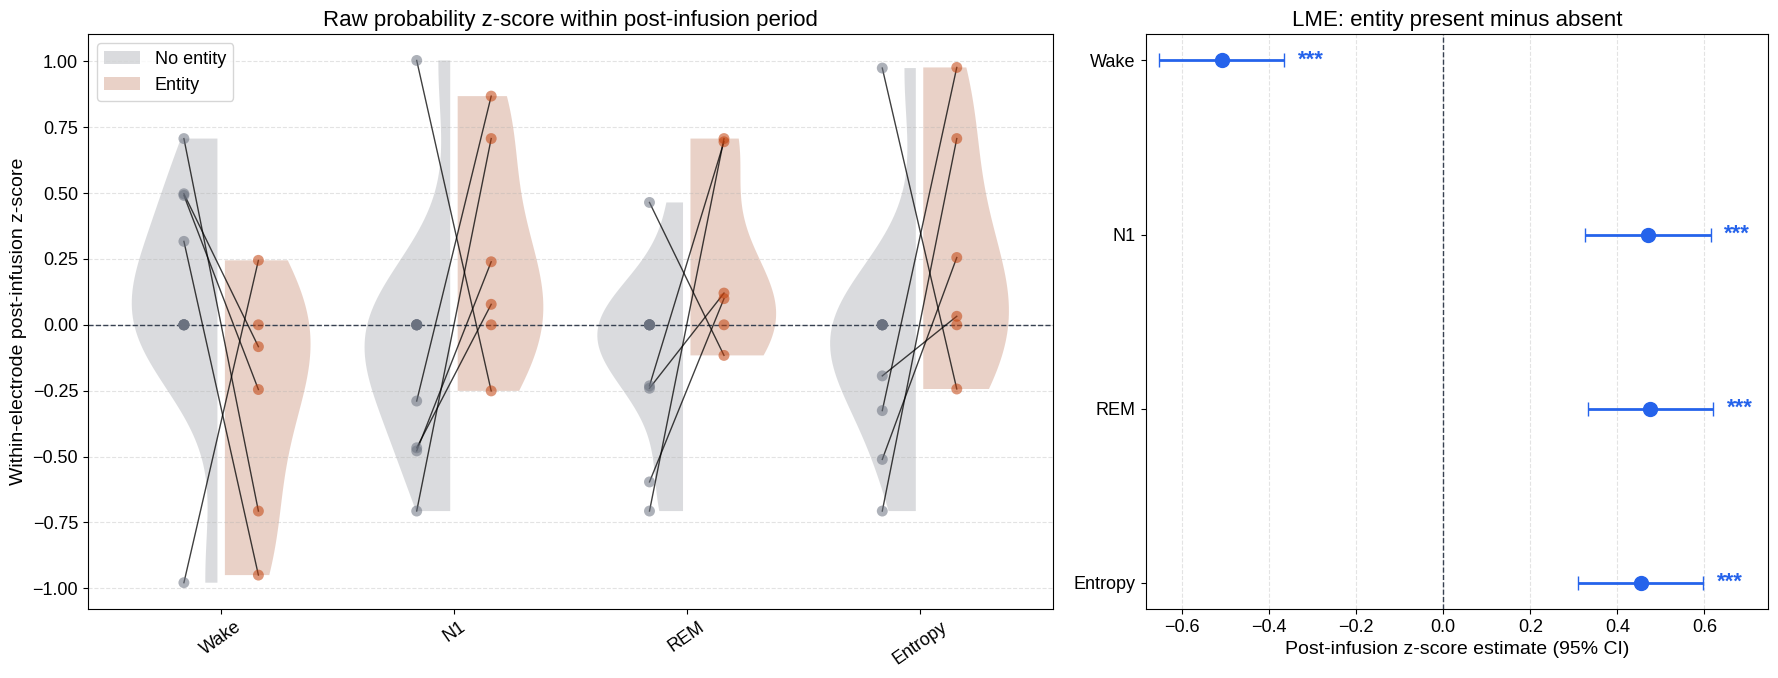

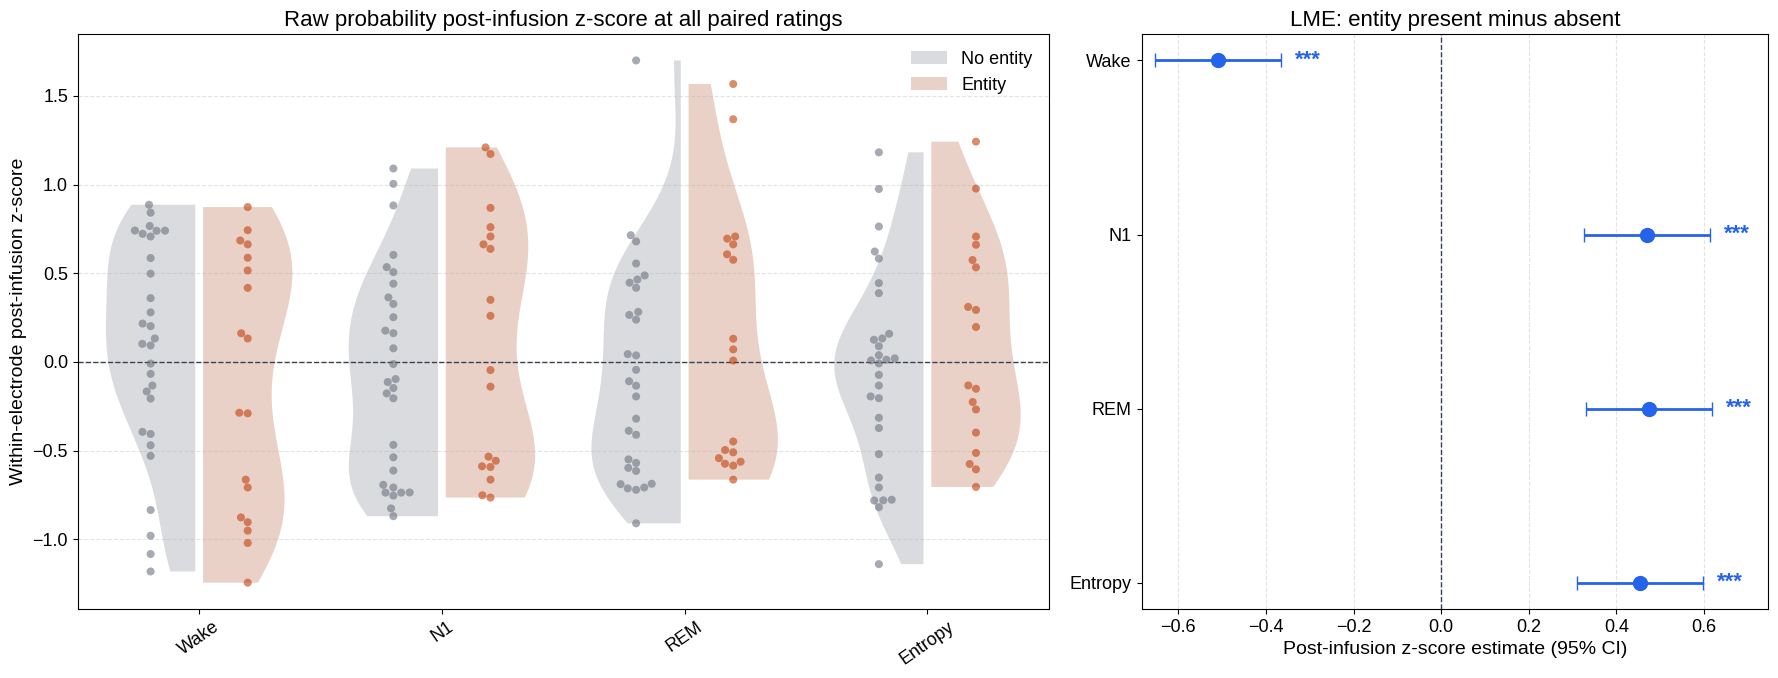

,subject,timepoint,entity,response,value,entity_label
156,P07,0,0,Entropy,NaN,No entity
157,P08,0,0,Entropy,-0.818120,No entity
158,P08,10,0,Entropy,-0.203951,No entity
163,P09,0,0,Entropy,-0.372274,No entity
164,P09,14,0,Entropy,0.444660,No entity
...,...,...,...,...,...,...
35,P22,4,1,Wake,-0.950211,Entity
39,P23,2,1,Wake,-0.285827,Entity
40,P23,3,1,Wake,0.515855,Entity
41,P23,10,1,Wake,0.587265,Entity


'Saved figure files to /home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/entities_lme_analysis_gssc_v4_postinfusion_zscore/figures'

In [62]:
post_z_subject_state_means = (
    entity_electrode_post_z.groupby(['subject', 'entity'], observed=True)[list(RESPONSES)].mean().reset_index()
)
post_z_plot_data = post_z_subject_state_means.melt(
    id_vars=['subject', 'entity'], value_vars=list(RESPONSES), var_name='response', value_name='value'
)
post_z_plot_data['response'] = post_z_plot_data['response'].map(RESPONSE_LABELS)
post_z_plot_data['entity_label'] = post_z_plot_data['entity'].map(ENTITY_LABELS)
post_z_effects = post_z_lme_results.copy()
post_z_effects['response'] = pd.Categorical(post_z_effects['response'], categories=response_order, ordered=True)
post_z_effects = post_z_effects.sort_values('response').reset_index(drop=True)

def draw_post_z_forest(axis):
    y_positions = np.arange(len(post_z_effects))
    x_span = post_z_effects['ci95_high'].max() - post_z_effects['ci95_low'].min()
    significance_offset = max(0.005, 0.025 * x_span)
    for y, (_, row) in zip(y_positions, post_z_effects.iterrows()):
        axis.errorbar(row['beta'], y, xerr=[[row['beta'] - row['ci95_low']], [row['ci95_high'] - row['beta']]], fmt='o', color='#2563eb', ecolor='#2563eb', capsize=5, markersize=10, linewidth=2)
        if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001: axis.text(row['ci95_high'] + significance_offset, y, '***', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
        elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.01: axis.text(row['ci95_high'] + significance_offset, y, '**', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
        elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.05: axis.text(row['ci95_high'] + significance_offset, y, '*', color='#2563eb', fontsize=16, va='center', ha='left', fontweight='bold')
    axis.axvline(0, color='#374151', linewidth=1, linestyle='--')
    axis.set_xlim(post_z_effects['ci95_low'].min() - significance_offset, post_z_effects['ci95_high'].max() + 4 * significance_offset)
    axis.set_yticks(y_positions, post_z_effects['response']); axis.invert_yaxis()
    axis.set(title='LME: entity present minus absent', xlabel='Post-infusion z-score estimate (95% CI)')
    axis.grid(axis='x', linestyle='--', alpha=0.35)

figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(data=post_z_plot_data, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, split=True, inner=None, palette=palette, cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.25)
for response_position, response in enumerate(response_order):
    response_subset = post_z_plot_data.loc[post_z_plot_data['response'].eq(response)]
    paired = response_subset.pivot(index='subject', columns='entity_label', values='value').dropna(subset=entity_order, how='any')
    for _, paired_subject in paired.iterrows(): axis.plot([response_position + point_offsets[entity_order[0]], response_position + point_offsets[entity_order[1]]], [paired_subject[entity_order[0]], paired_subject[entity_order[1]]], color='black', linewidth=1, alpha=0.75, zorder=3)
    for entity_label in entity_order:
        values = response_subset.loc[response_subset['entity_label'].eq(entity_label), 'value']
        axis.scatter(np.full(len(values), response_position + point_offsets[entity_label]), values, s=62, color=palette[entity_label], edgecolor='none', alpha=0.55, zorder=4)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set(title='Raw probability z-score within post-infusion period', xlabel='', ylabel='Within-electrode post-infusion z-score')
axis.tick_params(axis='x', rotation=35); axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None: legend.set_title(None)
draw_post_z_forest(axes[1])
figure.tight_layout()
for extension in ('png', 'svg', 'pdf'): figure.savefig(POST_Z_FIGURES_DIR / f'entities_hypnodensities_by_state_and_lme_raw_probability_postinfusion_zscore.{extension}', dpi=300, bbox_inches='tight')
plt.show()

auto_post_z_timepoint_means = entity_electrode_post_z.groupby(['subject', 'timepoint', 'entity'], observed=True)[list(RESPONSES)].mean().reset_index()
auto_post_z_timepoint_means.to_csv(POST_Z_OUTPUT_DIR / 'entity_timepoint_raw_probability_postinfusion_zscore_means.csv', index=False)
post_z_all_points = auto_post_z_timepoint_means.melt(id_vars=['subject', 'timepoint', 'entity'], value_vars=list(RESPONSES), var_name='response', value_name='value')
post_z_all_points['response'] = post_z_all_points['response'].map(RESPONSE_LABELS); post_z_all_points['entity_label'] = post_z_all_points['entity'].map(ENTITY_LABELS)
figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(data=post_z_all_points, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, split=True, inner=None, palette=palette, cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.25)
sns.swarmplot(data=post_z_all_points, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, dodge=True, palette=palette, size=5.8, alpha=0.60, edgecolor='none', linewidth=0, ax=axis)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set(title='Raw probability post-infusion z-score at all paired ratings', xlabel='', ylabel='Within-electrode post-infusion z-score')
axis.tick_params(axis='x', rotation=35); axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None:
    handles, labels = axis.get_legend_handles_labels(); legend.remove(); axis.legend(handles[:2], labels[:2], title=None, frameon=False)
draw_post_z_forest(axes[1])
figure.tight_layout()
for extension in ('png', 'svg', 'pdf'): figure.savefig(POST_Z_FIGURES_DIR / f'entities_hypnodensities_all_rating_points_raw_probability_postinfusion_zscore.{extension}', dpi=300, bbox_inches='tight')
plt.show()
display(post_z_all_points.sort_values(['response', 'entity', 'subject', 'timepoint']))
display(f'Saved figure files to {POST_Z_FIGURES_DIR}')